# VAE/GAN Training Notebook

Trains a VAE with an adversarial discriminator and feature-matching
reconstruction loss (Larsen et al., ICML 2016).

**Key differences from standard VAE training:**
- Three separate optimizers (encoder, decoder, discriminator)
- Three loss functions computed and backpropagated separately
- Reconstruction quality measured by discriminator feature similarity
  rather than pixel-wise MSE/BCE
- GAN dynamics require careful balancing of learning rates


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1 — Setup & Imports

In [5]:
import sys, os, time, json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/content/drive/MyDrive/Bayes_Project')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')
print(f'PyTorch:      {torch.__version__}')
print(f'CUDA:         {torch.cuda.is_available()}')


Project root: /content/drive/MyDrive/Bayes_Project
PyTorch:      2.10.0+cu128
CUDA:         True


In [6]:
from data.dataloader import get_dataloaders, IMAGE_SIZE
from models.base import get_model, MODEL_REGISTRY

import models.vae_gan  # noqa: F401

from train.train_utils import (
    MetricTracker,
    RunLog,
    Timer,
    compute_image_metrics,
    save_checkpoint,
    load_checkpoint,
)
from outputs.plotting import (
    plot_loss,
    plot_all_metrics,
    plot_reconstructions,
    plot_samples,
)

print('Available models:', list(MODEL_REGISTRY.keys()))


Available models: ['vae', 'conv_vae', 'vq_vae', 'vae_gan']


## 2 — Configuration

VAE/GAN has additional hyperparameters controlling the balance
between the three loss terms.

In [ ]:
# Model
MODEL_KEY       = 'vae_gan'
LATENT_DIM      = 64
HIDDEN_DIMS     = [32, 64, 128, 256]  # encoder/decoder channels
DISC_DIMS       = [32, 64, 128, 256]  # discriminator channels (None = same)

# Loss Weights
KL_WEIGHT       = 0.5             # weight on KL divergence
FEAT_WEIGHT     = 1.0             # weight on feature-matching loss
ADV_WEIGHT      = 0.5             # weight on adversarial loss for decoder

# KL Annealing
KL_ANNEAL_EPOCHS = 10             # ramp kl_weight 0 → KL_WEIGHT

# Data
DATASET         = 'fashion_mnist'
BATCH_SIZE      = 128
NUM_WORKERS     = 2
DATA_ROOT       = str(PROJECT_ROOT / 'data' / 'raw')

# Training
EPOCHS          = 50
LR_ENC          = 1e-4            # encoder learning rate
LR_DEC          = 1e-4            # decoder/generator learning rate
LR_DISC         = 2e-4            # discriminator learning rate (typically 2-4x)
WEIGHT_DECAY    = 1e-5
DISC_STEPS      = 1               # disc updates per generator update
PRECISION       = 'fp32'

# Logging
CHECKPOINT_DIR  = str(PROJECT_ROOT / 'models' / 'checkpoints')
LOG_DIR         = str(PROJECT_ROOT / 'logs')
OUTPUT_DIR      = str(PROJECT_ROOT / 'outputs')
SAVE_EVERY      = 10
RUN_NAME        = None

# Misc
SEED            = 42
DEVICE          = None


## 3 — Device & Seed

In [8]:
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if DEVICE:
    device = torch.device(DEVICE)
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')


Device: cuda


## 4 — Data

In [9]:
train_loader, test_loader, channels = get_dataloaders(
    dataset_name=DATASET,
    batch_size=BATCH_SIZE,
    data_root=DATA_ROOT,
    num_workers=NUM_WORKERS,
)

print(f'Dataset:      {DATASET}')
print(f'Channels:     {channels}')
print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')


Dataset:      fashion_mnist
Channels:     1
Train batches: 468
Test batches:  79


### Quick data preview

Batch shape: torch.Size([128, 1, 32, 32])


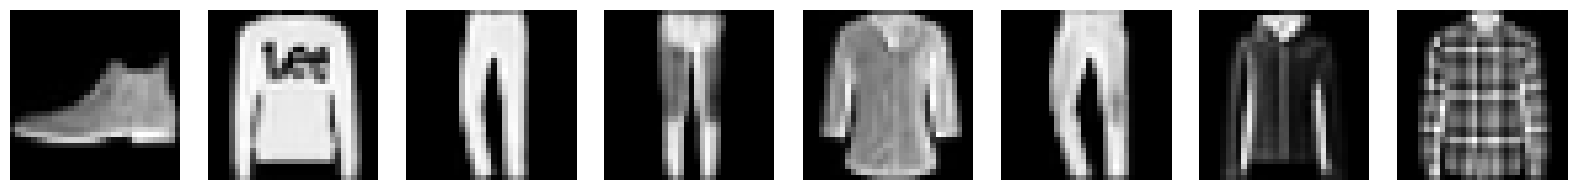

In [10]:
sample_batch, _ = next(iter(test_loader))
print(f'Batch shape: {sample_batch.shape}')

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i in range(8):
    img = sample_batch[i]
    if img.shape[0] == 1:
        axes[i].imshow(img.squeeze(0), cmap='gray')
    else:
        axes[i].imshow(img.permute(1, 2, 0))
    axes[i].axis('off')
plt.tight_layout()
plt.show()


## 5 — Model

In [11]:
model = get_model(
    MODEL_KEY,
    input_channels=channels,
    image_size=IMAGE_SIZE,
    hidden_dims=HIDDEN_DIMS,
    latent_dim=LATENT_DIM,
    kl_weight=KL_WEIGHT,
    feat_weight=FEAT_WEIGHT,
    adv_weight=ADV_WEIGHT,
    disc_dims=DISC_DIMS,
).to(device)

enc_params  = sum(p.numel() for p in model.encoder.parameters())
dec_params  = sum(p.numel() for p in model.decoder.parameters())
disc_params = sum(p.numel() for p in model.discriminator.parameters())

print(f'Model:         {model.model_name}')
print(f'Encoder:       {enc_params:,} params')
print(f'Decoder:       {dec_params:,} params')
print(f'Discriminator: {disc_params:,} params')
print(f'Total:         {enc_params + dec_params + disc_params:,} params')
print(f'Latent dim:    {model.get_latent_dim()}')


Model:         vae_gan
Encoder:       520,000 params
Decoder:       454,593 params
Discriminator: 650,497 params
Total:         1,625,090 params
Latent dim:    64


## 6 — Three Optimizers

Each component gets its own optimizer. The discriminator typically
uses a higher learning rate to stay ahead of the generator.

In [12]:
opt_enc = torch.optim.Adam(
    model.encoder.parameters(), lr=LR_ENC, weight_decay=WEIGHT_DECAY,
    betas=(0.5, 0.999)
)
opt_dec = torch.optim.Adam(
    model.decoder.parameters(), lr=LR_DEC, weight_decay=WEIGHT_DECAY,
    betas=(0.5, 0.999)
)
opt_disc = torch.optim.Adam(
    model.discriminator.parameters(), lr=LR_DISC,
    betas=(0.5, 0.999)
)

print(f'Encoder LR:       {LR_ENC}')
print(f'Decoder LR:       {LR_DEC}')
print(f'Discriminator LR: {LR_DISC}')
print(f'Betas:            (0.5, 0.999)')


Encoder LR:       0.0001
Decoder LR:       0.0001
Discriminator LR: 0.0002
Betas:            (0.5, 0.999)


## 7 — Run Log Initialisation

In [13]:
dims_tag = '-'.join(str(d) for d in HIDDEN_DIMS)
run_name = RUN_NAME or f'{model.model_name}_{DATASET}_h{dims_tag}_z{LATENT_DIM}_{PRECISION}'

run_log = RunLog(
    model_name=model.model_name,
    dataset=DATASET,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LR_ENC,
    latent_dim=LATENT_DIM,
    kl_weight=KL_WEIGHT,
    optimizer_name='Adam (3x)',
    scheduler_name='none',
    precision=PRECISION,
    device=str(device),
    seed=SEED,
    extra_hparams={
        'hidden_dims': HIDDEN_DIMS,
        'disc_dims': DISC_DIMS,
        'feat_weight': FEAT_WEIGHT,
        'adv_weight': ADV_WEIGHT,
        'lr_enc': LR_ENC,
        'lr_dec': LR_DEC,
        'lr_disc': LR_DISC,
        'disc_steps': DISC_STEPS,
        'kl_anneal_epochs': KL_ANNEAL_EPOCHS,
    },
)

log_path = Path(LOG_DIR) / f'{run_name}.json'
ckpt_dir = Path(CHECKPOINT_DIR)
out_dir  = Path(OUTPUT_DIR)

for d in [log_path.parent, ckpt_dir, out_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Run name: {run_name}')
print(f'Log path: {log_path}')


Run name: vae_gan_fashion_mnist_h32-64-128-256_z64_fp32
Log path: /content/drive/MyDrive/Bayes_Project/logs/vae_gan_fashion_mnist_h32-64-128-256_z64_fp32.json


## 8 — Training & Evaluation Functions

The training loop alternates three steps per batch:
1. **Discriminator**: learn to separate real from reconstructed
2. **Encoder**: minimize KL + feature-matching loss
3. **Decoder**: minimize feature-matching + adversarial loss

The discriminator sees `.detach()`ed reconstructions so its
gradients don't flow into the encoder/decoder.

In [ ]:
def train_one_epoch(model, loader, opt_enc, opt_dec, opt_disc,
                     device, tracker, disc_steps=1):
    model.train()
    for batch_data, _ in loader:
        batch_data = batch_data.to(device)
        batch_size = batch_data.size(0)

        # Discriminator
        for _ in range(disc_steps):
            with torch.no_grad():
                model_output = model.forward(batch_data)
                recon = model_output['recon']

            disc_losses = model.compute_disc_loss(batch_data, recon)
            opt_disc.zero_grad()
            disc_losses['disc_loss'].backward()
            opt_disc.step()

        # Encoder
        model_output = model.forward(batch_data)
        recon = model_output['recon']
        mu = model_output['mu']
        logvar = model_output['logvar']

        with torch.no_grad():
            feat_real = model.discriminate(batch_data)['features']
        feat_recon = model.discriminate(recon)['features']

        enc_losses = model.compute_enc_loss(
            mu, logvar, feat_real, feat_recon,
        )
        opt_enc.zero_grad()
        enc_losses['enc_loss'].backward()
        opt_enc.step()

        # Decoder
        model_output = model.forward(batch_data)
        recon = model_output['recon']

        with torch.no_grad():
            feat_real = model.discriminate(batch_data)['features']
        feat_recon = model.discriminate(recon)['features']

        dec_losses = model.compute_dec_loss(
            recon, feat_real, feat_recon,
        )
        opt_dec.zero_grad()
        dec_losses['dec_loss'].backward()
        opt_dec.step()

        # Metrics
        with torch.no_grad():
            recon_final = model.forward(batch_data)['recon']
            img_metrics = compute_image_metrics(recon_final, batch_data)

            loss_dict = {
                'total_loss': enc_losses['enc_loss'].detach() + dec_losses['dec_loss'].detach(),
                'recon_loss': enc_losses['feat_match_loss'].detach(),
                'kl_loss': enc_losses['kl_loss'].detach(),
                'disc_loss': disc_losses['disc_loss'].detach(),
                'gen_adv_loss': dec_losses['gen_adv_loss'].detach(),
                'feat_match_loss': enc_losses['feat_match_loss'].detach(),
            }

        extra_dict = {
            'disc_loss': disc_losses['disc_loss'].detach(),
            'gen_adv_loss': dec_losses['gen_adv_loss'].detach(),
            'feat_match_loss': enc_losses['feat_match_loss'].detach(),
        }

        tracker.update(loss_dict, img_metrics, extra_dict, batch_size)


@torch.no_grad()
def evaluate(model, loader, device, tracker):
    model.eval()
    for batch_data, _ in loader:
        batch_data = batch_data.to(device)
        batch_size = batch_data.size(0)

        model_output = model.forward(batch_data)
        recon = model_output['recon']

        loss_dict = model.loss_function(model_output, batch_data)

        disc_real = model.discriminate(batch_data)
        disc_recon = model.discriminate(recon)
        feat_loss = model.feature_matching_loss(
            disc_real['features'], disc_recon['features']
        )

        real_labels = torch.ones_like(disc_real['logit'])
        fake_labels = torch.zeros_like(disc_recon['logit'])
        disc_loss = 0.5 * (
            F.binary_cross_entropy_with_logits(disc_real['logit'], real_labels) +
            F.binary_cross_entropy_with_logits(disc_recon['logit'], fake_labels)
        )
        adv_loss = F.binary_cross_entropy_with_logits(disc_recon['logit'], real_labels)

        loss_dict['disc_loss'] = disc_loss
        loss_dict['gen_adv_loss'] = adv_loss
        loss_dict['feat_match_loss'] = feat_loss

        img_metrics = compute_image_metrics(recon, batch_data)

        extra_dict = {
            'disc_loss': disc_loss,
            'gen_adv_loss': adv_loss,
            'feat_match_loss': feat_loss,
        }

        tracker.update(loss_dict, img_metrics, extra_dict, batch_size)


## 9 — Training Loop

In [ ]:
timer = Timer()
timer.start()
best_loss = float('inf')

live_train_loss = []
live_val_loss   = []
live_disc_loss  = []
live_adv_loss   = []

print(f'Starting VAE/GAN training for {EPOCHS} epochs …')
if KL_ANNEAL_EPOCHS > 0:
    print(f'KL annealing: 0 → {KL_WEIGHT} over first {KL_ANNEAL_EPOCHS} epochs')
print()

for epoch in range(1, EPOCHS + 1):

    if KL_ANNEAL_EPOCHS > 0:
        model.kl_weight = KL_WEIGHT * min(1.0, epoch / KL_ANNEAL_EPOCHS)

    # train
    train_tracker = MetricTracker(extra_keys=model.extra_metrics)
    train_one_epoch(
        model, train_loader, opt_enc, opt_dec, opt_disc,
        device, train_tracker, disc_steps=DISC_STEPS
    )
    train_summary = train_tracker.summarise()

    # evaluate
    eval_tracker = MetricTracker(extra_keys=model.extra_metrics)
    evaluate(model, test_loader, device, eval_tracker)
    eval_summary = eval_tracker.summarise()

    epoch_record = {
        'epoch': epoch,
        **{f'train_{k}': v for k, v in train_summary.items()},
        **{f'val_{k}': v for k, v in eval_summary.items()},
    }
    run_log.epoch_history.append(epoch_record)

    val_loss = eval_summary.get('recon_loss', eval_summary.get('total_loss'))
    live_train_loss.append(train_summary.get('feat_match_loss', 0))
    live_val_loss.append(eval_summary.get('feat_match_loss', 0))
    live_disc_loss.append(train_summary.get('disc_loss', 0))
    live_adv_loss.append(train_summary.get('gen_adv_loss', 0))

    print(
        f'  Epoch {epoch:3d}/{EPOCHS}  |  '
        f'feat={train_summary.get("feat_match_loss", 0):.4f}  '
        f'kl={train_summary.get("kl_loss", 0):.4f}  '
        f'D={train_summary.get("disc_loss", 0):.4f}  '
        f'G_adv={train_summary.get("gen_adv_loss", 0):.4f}  '
        f'psnr={eval_summary.get("psnr", 0):.2f}  '
        f'ssim={eval_summary.get("ssim", 0):.4f}  '
        f'kl_w={model.kl_weight:.3f}'
    )

    # Checkpoint
    is_best = val_loss < best_loss
    if is_best:
        best_loss = val_loss
        run_log.best_epoch = epoch
        run_log.best_total_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'opt_enc': opt_enc.state_dict(),
            'opt_dec': opt_dec.state_dict(),
            'opt_disc': opt_disc.state_dict(),
            'metrics': eval_summary,
        }, ckpt_dir / f'{run_name}_best.pt')

    if SAVE_EVERY > 0 and epoch % SAVE_EVERY == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'opt_enc': opt_enc.state_dict(),
            'opt_dec': opt_dec.state_dict(),
            'opt_disc': opt_disc.state_dict(),
            'metrics': eval_summary,
        }, ckpt_dir / f'{run_name}_epoch{epoch}.pt')

    run_log.total_training_time_sec = timer.elapsed()
    run_log.save(log_path)

run_log.total_training_time_sec = timer.elapsed()
run_log.save(log_path)

print(f'\nFinished in {run_log.total_training_time_sec:.1f}s')
print(f'Best val feat_loss={run_log.best_total_loss:.4f} at epoch {run_log.best_epoch}')


Starting VAE/GAN training for 50 epochs …
KL annealing: 0 → 0.5 over first 10 epochs

  Epoch   1/50  |  feat=0.0198  kl=0.2768  D=0.3293  G_adv=1.4951  psnr=9.07  ssim=0.1258  kl_w=0.050
  Epoch   2/50  |  feat=0.0182  kl=0.0206  D=0.5097  G_adv=1.0229  psnr=8.60  ssim=0.1445  kl_w=0.100
  Epoch   3/50  |  feat=0.0177  kl=0.0127  D=0.5941  G_adv=0.8663  psnr=8.58  ssim=0.1700  kl_w=0.150
  Epoch   4/50  |  feat=0.0186  kl=0.0090  D=0.6298  G_adv=0.8087  psnr=8.57  ssim=0.1838  kl_w=0.200
  Epoch   5/50  |  feat=0.0213  kl=0.0070  D=0.6447  G_adv=0.7847  psnr=8.38  ssim=0.1839  kl_w=0.250
  Epoch   6/50  |  feat=0.0241  kl=0.0058  D=0.6519  G_adv=0.7775  psnr=8.49  ssim=0.1884  kl_w=0.300
  Epoch   7/50  |  feat=0.0269  kl=0.0051  D=0.6548  G_adv=0.7741  psnr=8.54  ssim=0.1862  kl_w=0.350
  Epoch   8/50  |  feat=0.0304  kl=0.0042  D=0.6565  G_adv=0.7671  psnr=8.68  ssim=0.1947  kl_w=0.400
  Epoch   9/50  |  feat=0.0337  kl=0.0038  D=0.6578  G_adv=0.7657  psnr=8.71  ssim=0.1990  kl_w=0.

## 10 — GAN Dynamics Plot

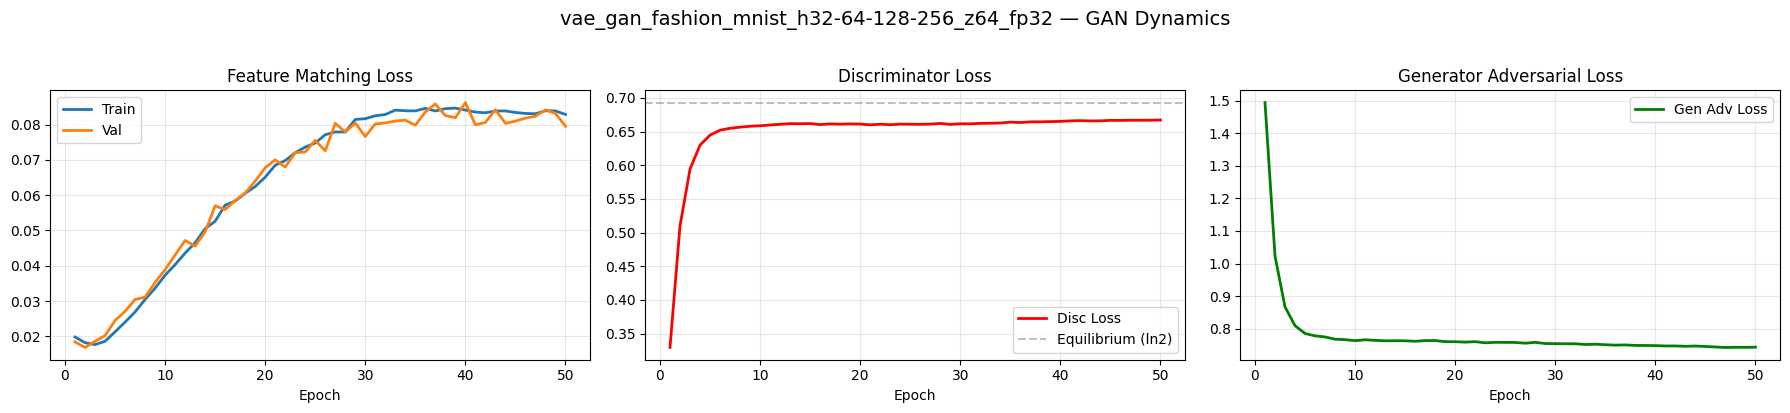

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs_range = range(1, len(live_train_loss) + 1)

# Feature matching loss
axes[0].plot(epochs_range, live_train_loss, label='Train', linewidth=2)
axes[0].plot(epochs_range, live_val_loss, label='Val', linewidth=2)
axes[0].set_title('Feature Matching Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Discriminator loss
axes[1].plot(epochs_range, live_disc_loss, label='Disc Loss', color='red', linewidth=2)
axes[1].axhline(y=0.693, color='gray', linestyle='--', alpha=0.5, label='Equilibrium (ln2)')
axes[1].set_title('Discriminator Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Generator adversarial loss
axes[2].plot(epochs_range, live_adv_loss, label='Gen Adv Loss', color='green', linewidth=2)
axes[2].set_title('Generator Adversarial Loss')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle(f'{run_name} — GAN Dynamics', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## 11 — Detailed Metrics

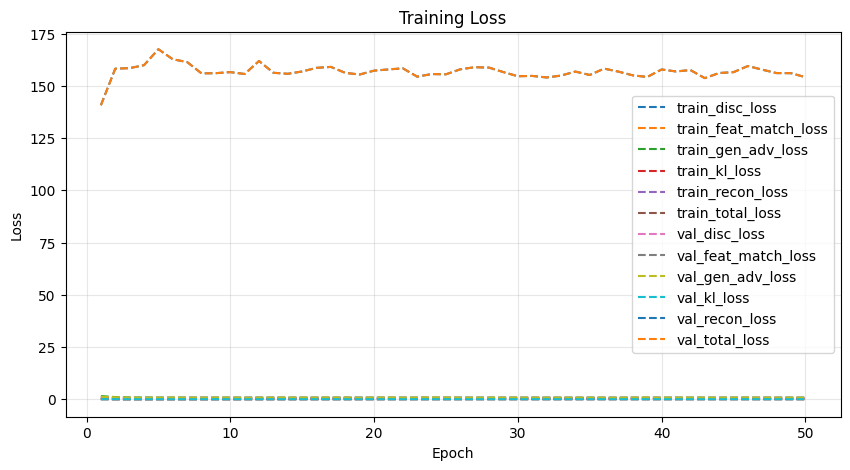

In [18]:
plot_loss(log_path, save_path=out_dir / f'{run_name}_loss.png', show=True)


In [20]:
plot_all_metrics(log_path, save_dir=out_dir, show=True)


[<Figure size 1000x400 with 1 Axes>,
 <Figure size 1000x400 with 1 Axes>,
 <Figure size 1000x400 with 1 Axes>,
 <Figure size 1000x400 with 1 Axes>]

## 12 — Reconstructions

Loaded best model from epoch 1


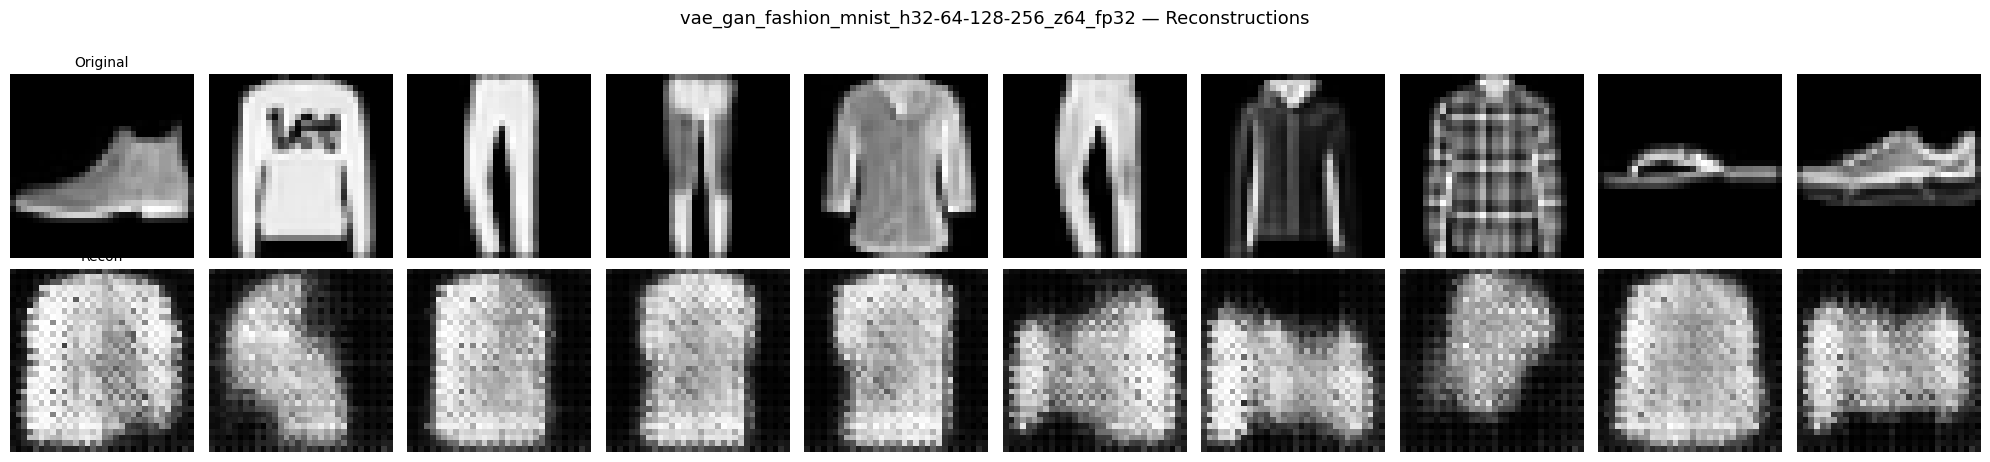

In [21]:
# Load best checkpoint
best_ckpt = torch.load(ckpt_dir / f'{run_name}_best.pt',
                        map_location=device, weights_only=False)
model.load_state_dict(best_ckpt['model_state_dict'])
print(f'Loaded best model from epoch {best_ckpt["epoch"]}')

test_batch, _ = next(iter(test_loader))

plot_reconstructions(
    model,
    test_batch,
    num_images=10,
    save_path=out_dir / f'{run_name}_reconstructions.png',
    title=f'{run_name} — Reconstructions',
    show=True,
)


## 13 — Generated Samples

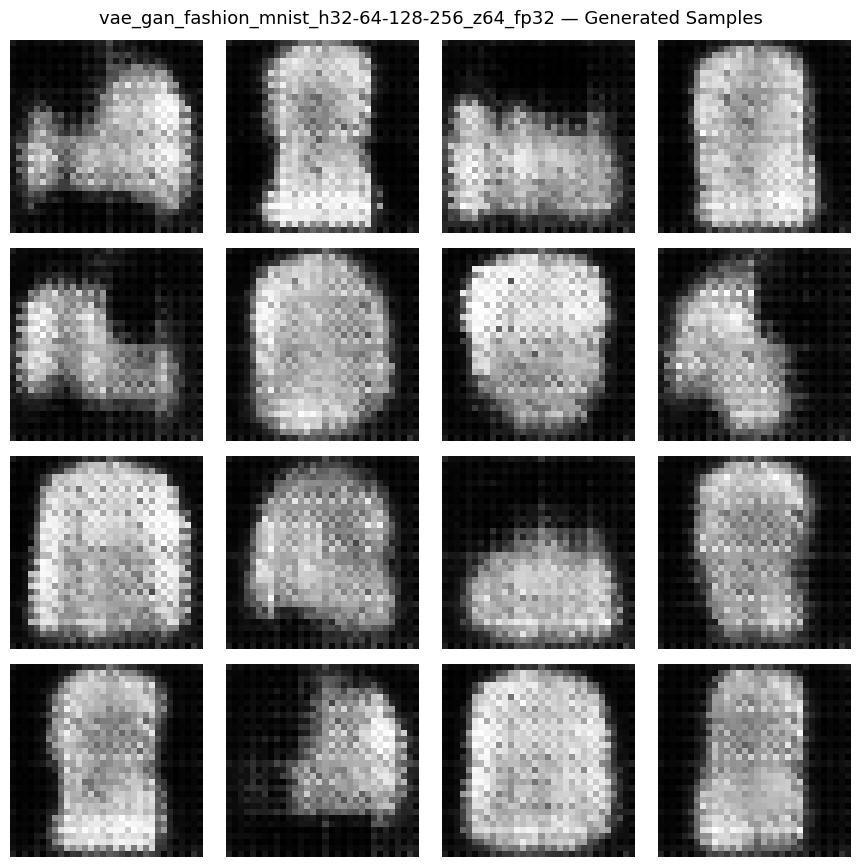

In [22]:
plot_samples(
    model,
    num_samples=16,
    nrow=4,
    save_path=out_dir / f'{run_name}_samples.png',
    title=f'{run_name} — Generated Samples',
    show=True,
)


## 14 — Run Summary

In [23]:
print('═' * 60)
print(f'  Model:          {run_log.model_name}')
print(f'  Dataset:        {run_log.dataset}')
print(f'  Precision:      {run_log.precision}')
print(f'  Epochs:         {run_log.epochs}')
print(f'  Best epoch:     {run_log.best_epoch}')
print(f'  Best feat loss: {run_log.best_total_loss:.4f}')
print(f'  Training time:  {run_log.total_training_time_sec:.1f}s')
print(f'  KL weight:      {KL_WEIGHT} (annealed over {KL_ANNEAL_EPOCHS} epochs)')
print(f'  Feat weight:    {FEAT_WEIGHT}')
print(f'  Adv weight:     {ADV_WEIGHT}')
print(f'  LR enc/dec/disc: {LR_ENC}/{LR_DEC}/{LR_DISC}')
print('═' * 60)
print(f'\nLog:  {log_path}')
print(f'Ckpt: {ckpt_dir / f"{run_name}_best.pt"}')


════════════════════════════════════════════════════════════
  Model:          vae_gan
  Dataset:        fashion_mnist
  Precision:      fp32
  Epochs:         50
  Best epoch:     1
  Best feat loss: 140.7020
  Training time:  2093.7s
  KL weight:      0.5 (annealed over 10 epochs)
  Feat weight:    1.0
  Adv weight:     0.5
  LR enc/dec/disc: 0.0001/0.0001/0.0002
════════════════════════════════════════════════════════════

Log:  /content/drive/MyDrive/Bayes_Project/logs/vae_gan_fashion_mnist_h32-64-128-256_z64_fp32.json
Ckpt: /content/drive/MyDrive/Bayes_Project/models/checkpoints/vae_gan_fashion_mnist_h32-64-128-256_z64_fp32_best.pt
